To run

First, run `generate_helper_array.py` from the `mace` dir.

```bash
sbatch benchmarks/generate_helper_array.py
```


Then, submit `run_hyper_array.csv`.

```bash
sbatch benchmarks/run_hyper_array.csv
```

Then run the following command

```bash
python tests/test_inference_hypers.py > benchmarks/inference_benchmarks.csv
```

In [1]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv('/home/s5f/twarf.s5f/maces/mace/benchmarks/inference_benchmarks.csv', converters={})
df.head()

,num_atoms,num_edges,dtype,cueq_enabled,num_interactions,max_ell,hidden_irreps,edge_irreps,correlation,interaction_cls,interaction_cls_first,max_memory_allocated,max_memory_reserved,device_name,median,Steps per day,ns/day (1 fs/step)
0,2744,433552,float32,True,1,2,32x0e+32x1o,64x0e+32x1o,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,1814402560,1849688064,NVIDIA GH200 120GB,0.010280,8.385904e+06,8.404837
1,2744,433552,float64,True,1,2,32x0e+32x1o,64x0e+32x1o,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,3553224192,3573547008,NVIDIA GH200 120GB,0.012269,7.036155e+06,7.042168
2,2744,433552,float32,True,2,2,32x0e+32x1o,64x0e+32x1o,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,6889630208,7941914624,NVIDIA GH200 120GB,0.048878,1.767205e+06,1.767663
3,2744,433552,float64,True,2,2,32x0e+32x1o,64x0e+32x1o,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,13699511296,16879976448,NVIDIA GH200 120GB,0.074623,1.157649e+06,1.157819
4,2744,433552,float32,True,1,2,32x0e+32x1o,64x0e+32x1o,3,RealAgnosticResidualNonLinearInteractionBlock,RealAgnosticResidualInteractionBlock,1814429184,1858076672,NVIDIA GH200 120GB,0.010391,8.255918e+06,8.315266


In [2]:
from e3nn import o3
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def string_to_scalar_vector(s):
    irreps = o3.Irreps(s)
    return irreps.count((0, 1)), irreps.count((1, -1))

df[['hidden_scalar', 'hidden_vector']] = df['hidden_irreps'].apply(string_to_scalar_vector).apply(pd.Series)
df[['edge_scalar', 'edge_vector']] = df['edge_irreps'].apply(string_to_scalar_vector).apply(pd.Series)

df.drop(['hidden_irreps', 'edge_irreps'], axis=1, inplace=True)

df['memory_allocated_GB'] = df['max_memory_allocated'] / (1024**3)

key_performance_metric = "ns/day (1 fs/step)"

df.head()

,num_atoms,num_edges,dtype,cueq_enabled,num_interactions,max_ell,correlation,interaction_cls,interaction_cls_first,max_memory_allocated,max_memory_reserved,device_name,median,Steps per day,ns/day (1 fs/step),hidden_scalar,hidden_vector,edge_scalar,edge_vector,memory_allocated_GB
0,2744,433552,float32,True,1,2,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,1814402560,1849688064,NVIDIA GH200 120GB,0.010280,8.385904e+06,8.404837,32,32,64,32,1.689794
1,2744,433552,float64,True,1,2,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,3553224192,3573547008,NVIDIA GH200 120GB,0.012269,7.036155e+06,7.042168,32,32,64,32,3.309198
2,2744,433552,float32,True,2,2,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,6889630208,7941914624,NVIDIA GH200 120GB,0.048878,1.767205e+06,1.767663,32,32,64,32,6.416468
3,2744,433552,float64,True,2,2,3,RealAgnosticResidualInteractionBlock,RealAgnosticResidualInteractionBlock,13699511296,16879976448,NVIDIA GH200 120GB,0.074623,1.157649e+06,1.157819,32,32,64,32,12.758664
4,2744,433552,float32,True,1,2,3,RealAgnosticResidualNonLinearInteractionBlock,RealAgnosticResidualInteractionBlock,1814429184,1858076672,NVIDIA GH200 120GB,0.010391,8.255918e+06,8.315266,32,32,64,32,1.689819


## Analysis

In [3]:
# Helper functions for detailed hyperparameter analysis


def calculate_regression_stats(x, y):
    """Calculate gradient, R², and correlation for regression analysis"""
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean, y_clean = x[mask], y[mask]
    
    if len(x_clean) < 2:
        return np.nan, np.nan, np.nan
    
    # Calculate gradient using linear regression
    X = x_clean.reshape(-1, 1)
    reg = LinearRegression().fit(X, y_clean)
    gradient = reg.coef_[0]
    
    # Calculate R²
    y_pred = reg.predict(X)
    r_squared = r2_score(y_clean, y_pred)
    
    # Calculate correlation
    correlation = np.corrcoef(x_clean, y_clean)[0, 1]
    
    return gradient, r_squared, correlation

def plot_hyperparameter_analysis(df_subset, title_suffix, hyperparams, performance_metric, memory_metric):
    """Plot scatter plots for hyperparameters vs performance and memory with stats"""
    n_params = len(hyperparams)
    fig, axes = plt.subplots(2, n_params, figsize=(5*n_params, 10))
    
    if n_params == 1:
        axes = axes.reshape(-1, 1)
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']
    
    for i, param in enumerate(hyperparams):
        if param not in df_subset.columns:
            continue
            
        x_data = df_subset[param].values
        y_perf = df_subset[performance_metric].values
        y_mem = df_subset[memory_metric].values
        
        # Count datapoints at each x position
        unique_x = np.unique(x_data)
        x_counts = {x: np.sum(x_data == x) for x in unique_x}
        
        # Performance plot
        axes[0, i].scatter(x_data, y_perf, alpha=0.6, color=colors[i % len(colors)])
        axes[0, i].set_xlabel(param)
        axes[0, i].set_ylabel(performance_metric)
        axes[0, i].set_title(f'{performance_metric} vs {param}\n{title_suffix}')
        axes[0, i].grid(True, alpha=0.3)
        
        # Add count annotations for performance plot
        for x_val, count in x_counts.items():
            y_positions = y_perf[x_data == x_val]
            if len(y_positions) > 0:
                # Place annotation at the top of the y-range for this x value
                y_max = np.max(y_positions)
                axes[0, i].annotate(f'n={count}', 
                                  xy=(x_val, y_max), 
                                  xytext=(0, 5), 
                                  textcoords='offset points',
                                  ha='center', va='bottom',
                                  fontsize=8, color='darkred',
                                  bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        
        # Calculate and display stats for performance
        grad_perf, r2_perf, corr_perf = calculate_regression_stats(x_data, y_perf)
        
        # Add trend line for performance
        if not np.isnan(grad_perf):
            x_sorted = np.sort(x_data)
            x_mean = np.mean(x_data)
            y_mean = np.mean(y_perf)
            y_trend = grad_perf * (x_sorted - x_mean) + y_mean
            axes[0, i].plot(x_sorted, y_trend, 'r--', alpha=0.8, linewidth=2)
            
            # Add stats text
            stats_text = f'Gradient: {grad_perf:.2e}\nR²: {r2_perf:.3f}\nCorr: {corr_perf:.3f}'
            axes[0, i].text(0.05, 0.95, stats_text, transform=axes[0, i].transAxes, 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                           verticalalignment='top', fontsize=8)
        
        # Memory plot
        axes[1, i].scatter(x_data, y_mem, alpha=0.6, color=colors[i % len(colors)])
        axes[1, i].set_xlabel(param)
        axes[1, i].set_ylabel(memory_metric)
        axes[1, i].set_title(f'{memory_metric} vs {param}\n{title_suffix}')
        axes[1, i].grid(True, alpha=0.3)
        
        # Add count annotations for memory plot
        for x_val, count in x_counts.items():
            y_positions = y_mem[x_data == x_val]
            if len(y_positions) > 0:
                # Place annotation at the top of the y-range for this x value
                y_max = np.max(y_positions)
                axes[1, i].annotate(f'n={count}', 
                                  xy=(x_val, y_max), 
                                  xytext=(0, 5), 
                                  textcoords='offset points',
                                  ha='center', va='bottom',
                                  fontsize=8, color='darkred',
                                  bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.7))
        
        # Calculate and display stats for memory
        grad_mem, r2_mem, corr_mem = calculate_regression_stats(x_data, y_mem)
        
        # Add trend line for memory
        if not np.isnan(grad_mem):
            y_mem_mean = np.mean(y_mem)
            y_mem_trend = grad_mem * (x_sorted - x_mean) + y_mem_mean
            axes[1, i].plot(x_sorted, y_mem_trend, 'r--', alpha=0.8, linewidth=2)
            
            # Add stats text
            stats_text = f'Gradient: {grad_mem:.3f}\nR²: {r2_mem:.3f}\nCorr: {corr_mem:.3f}'
            axes[1, i].text(0.05, 0.95, stats_text, transform=axes[1, i].transAxes,
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                           verticalalignment='top', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Define hyperparameters to analyze
numerical_hyperparams = ['max_ell', 'hidden_scalar', 'hidden_vector', 'edge_scalar', 'edge_vector']
print("Functions defined for hyperparameter analysis.")

Functions defined for hyperparameter analysis.


ANALYSIS: num_interactions=1, dtype=float32
Number of configurations: 384


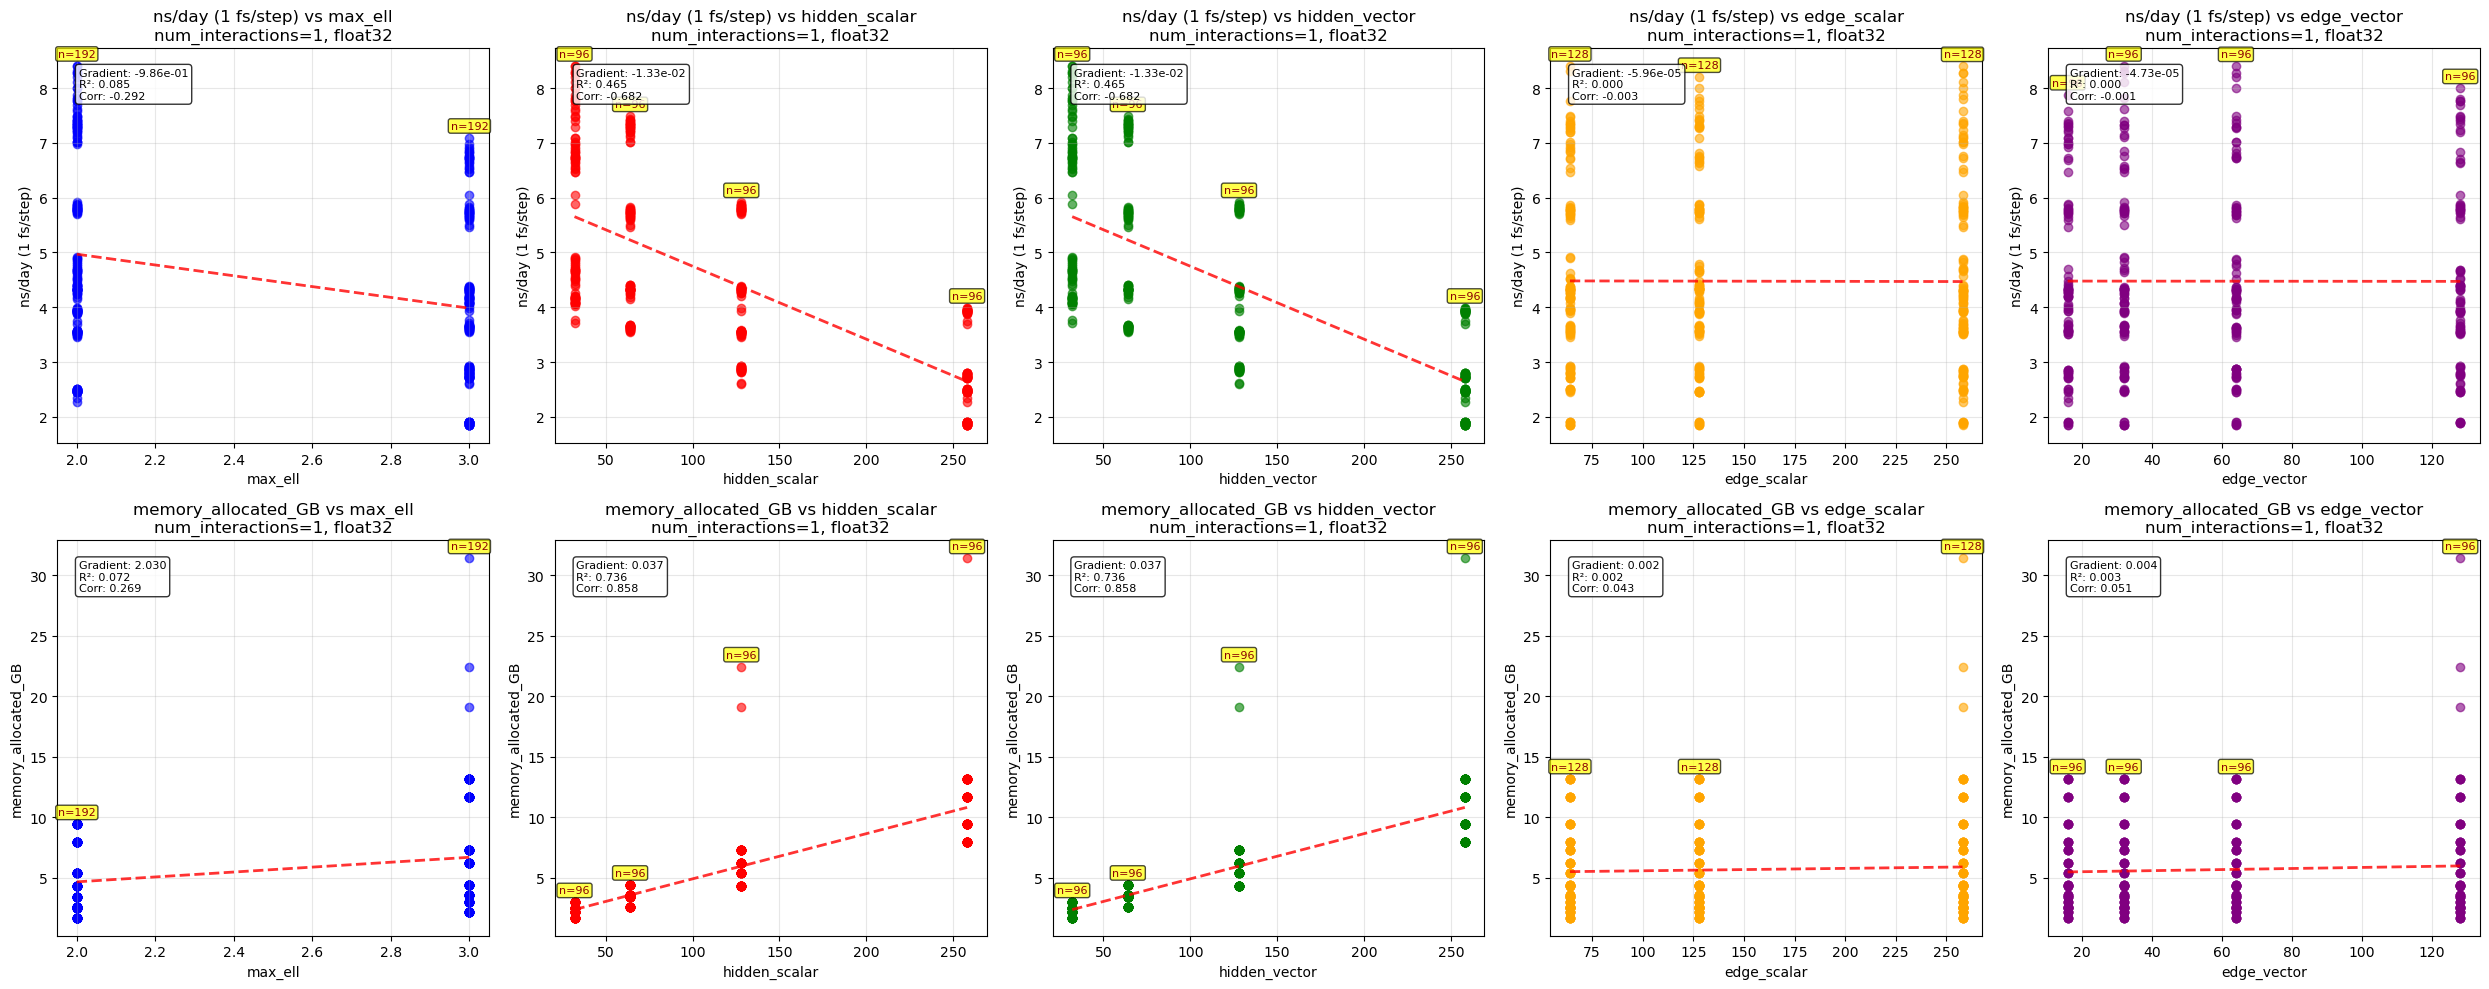

In [4]:
# Analysis for num_interactions == 1, dtype == float32
print("="*80)
print("ANALYSIS: num_interactions=1, dtype=float32")
print("="*80)

df_subset = df[(df['num_interactions'] == 1) & (df['dtype'] == 'float32')]
print(f"Number of configurations: {len(df_subset)}")

plot_hyperparameter_analysis(
    df_subset, 
    "num_interactions=1, float32", 
    numerical_hyperparams, 
    key_performance_metric, 
    'memory_allocated_GB'
)

ANALYSIS: num_interactions=1, dtype=float64
Number of configurations: 384


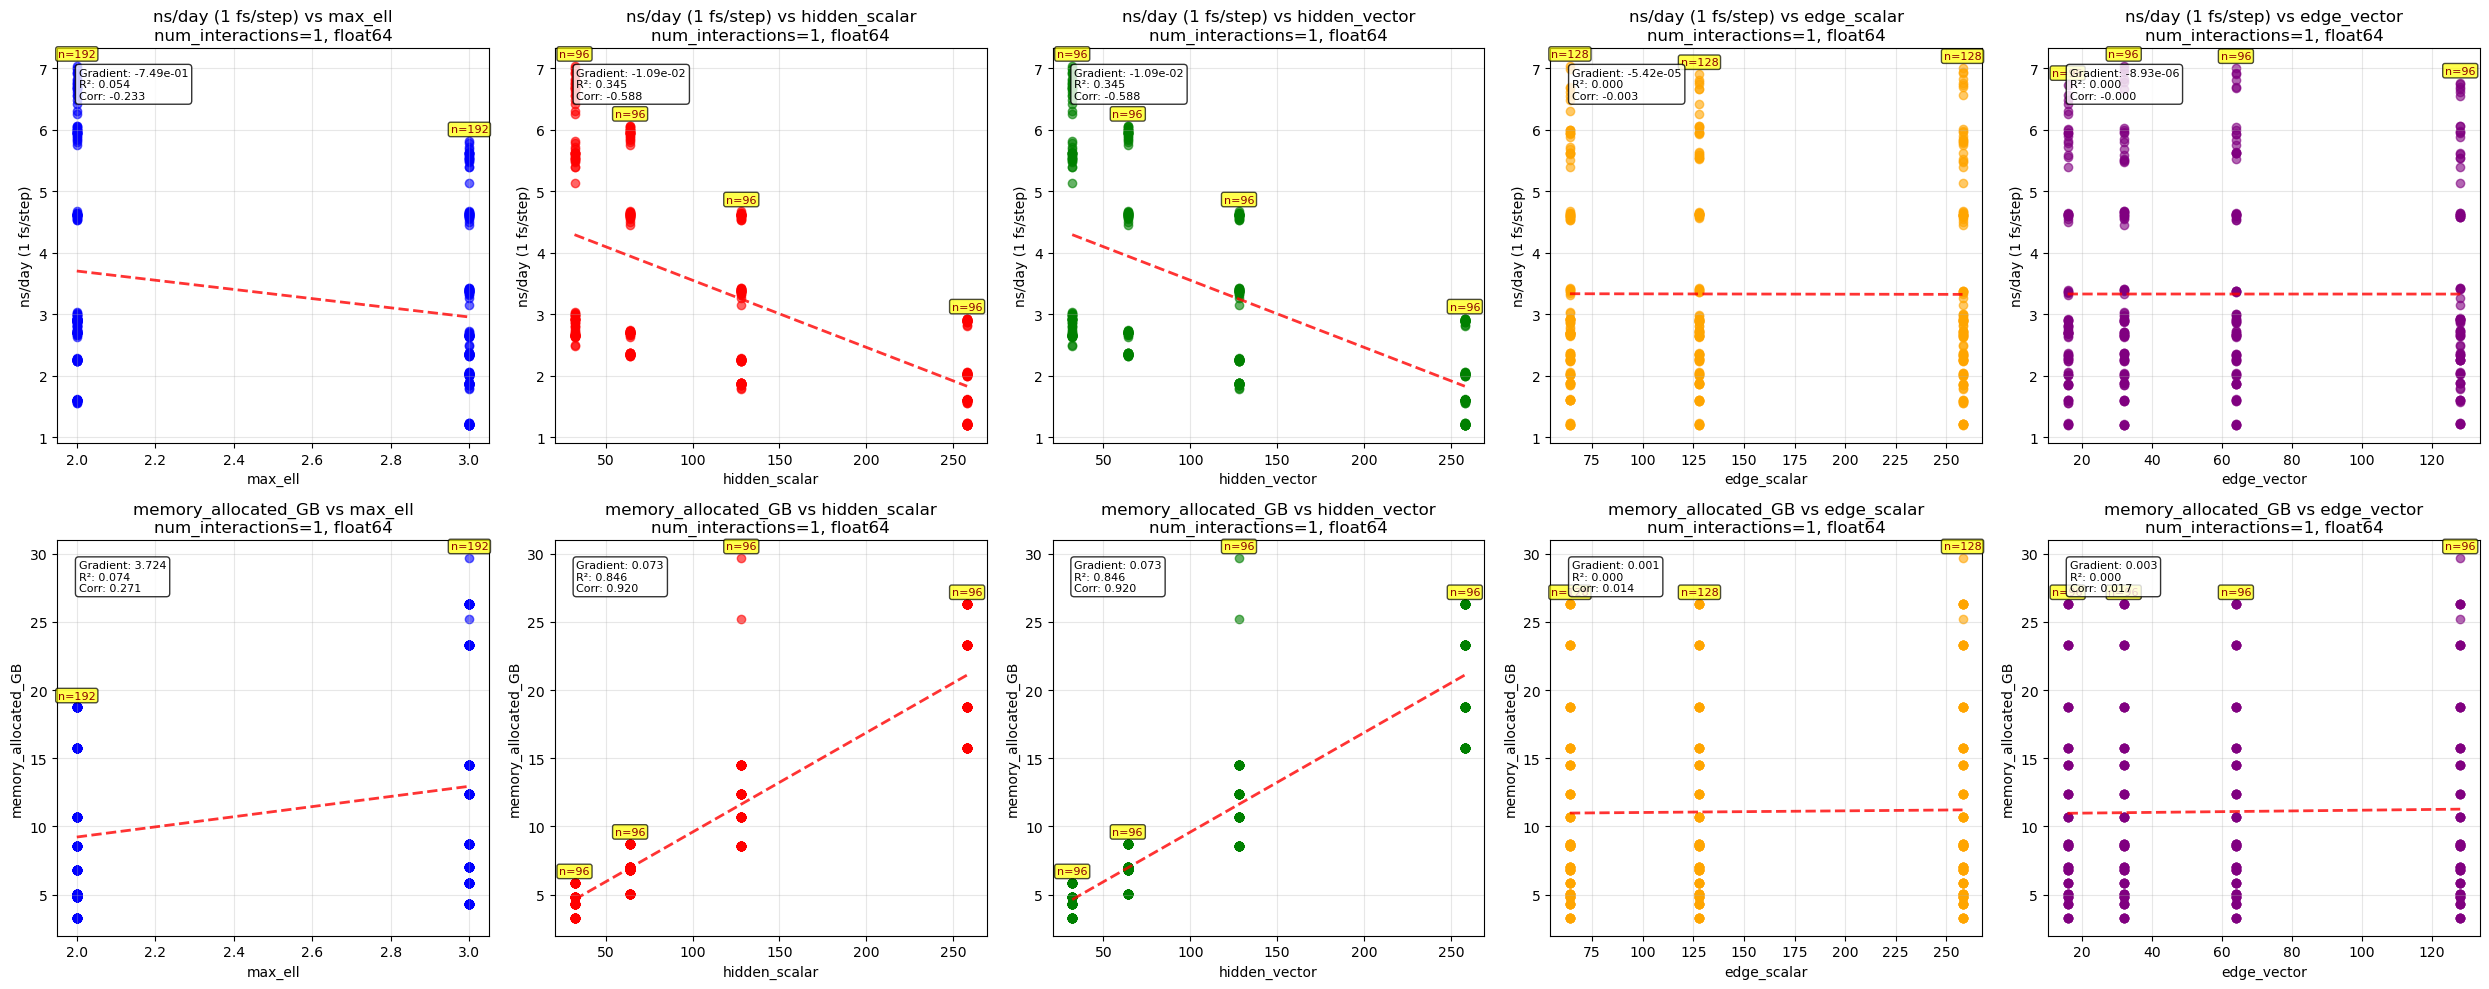

In [5]:
# Analysis for num_interactions == 1, dtype == float64
print("="*80)
print("ANALYSIS: num_interactions=1, dtype=float64")
print("="*80)

df_subset = df[(df['num_interactions'] == 1) & (df['dtype'] == 'float64')]
print(f"Number of configurations: {len(df_subset)}")

plot_hyperparameter_analysis(
    df_subset, 
    "num_interactions=1, float64", 
    numerical_hyperparams, 
    key_performance_metric, 
    'memory_allocated_GB'
)

ANALYSIS: num_interactions=2, dtype=float32
Number of configurations: 384


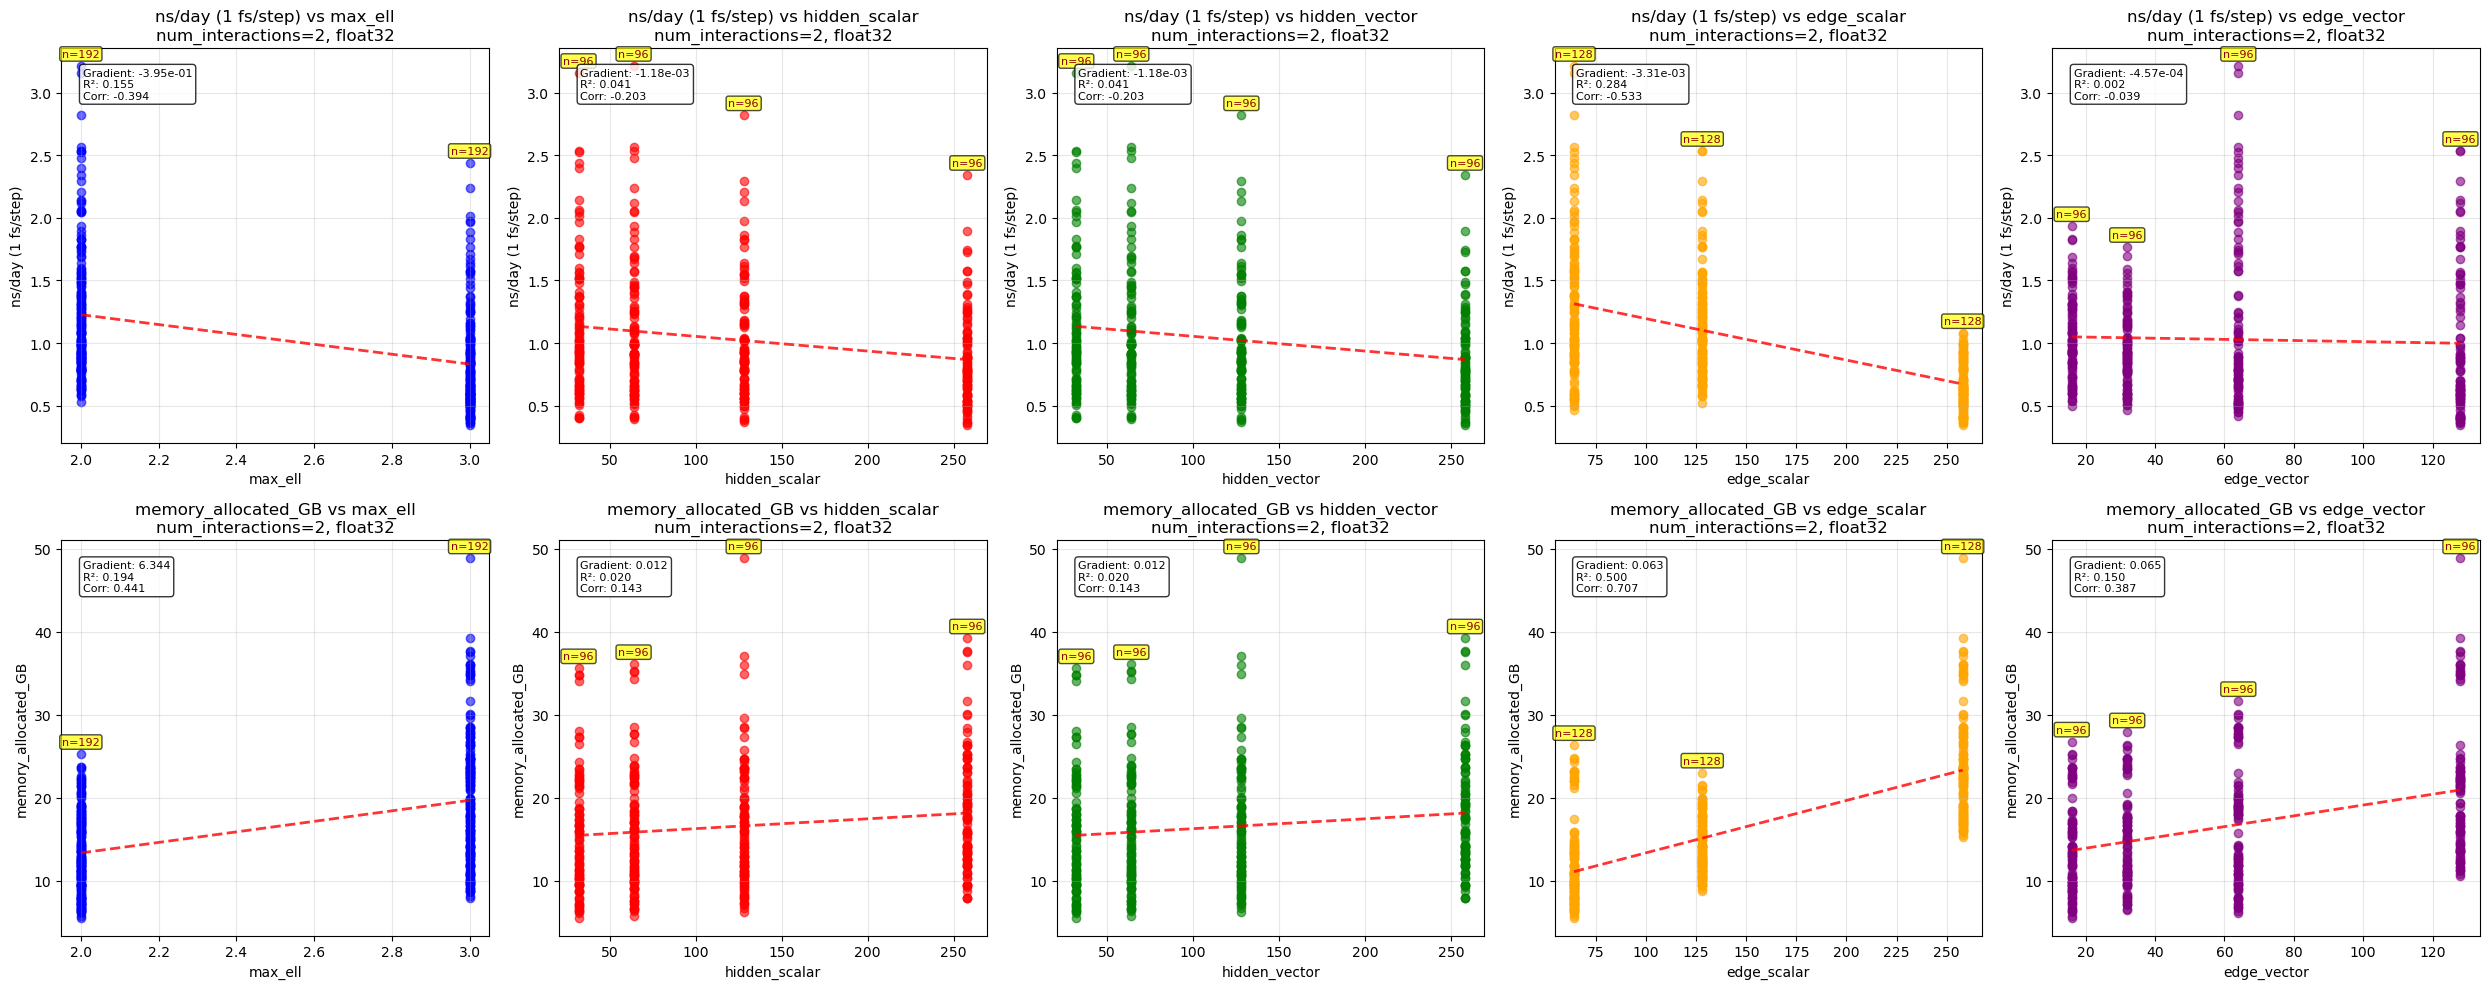

In [6]:
# Analysis for num_interactions == 2, dtype == float32
print("="*80)
print("ANALYSIS: num_interactions=2, dtype=float32")
print("="*80)

df_subset = df[(df['num_interactions'] == 2) & (df['dtype'] == 'float32')]
print(f"Number of configurations: {len(df_subset)}")

plot_hyperparameter_analysis(
    df_subset, 
    "num_interactions=2, float32", 
    numerical_hyperparams, 
    key_performance_metric, 
    'memory_allocated_GB'
)

ANALYSIS: num_interactions=2, dtype=float64
Number of configurations: 379


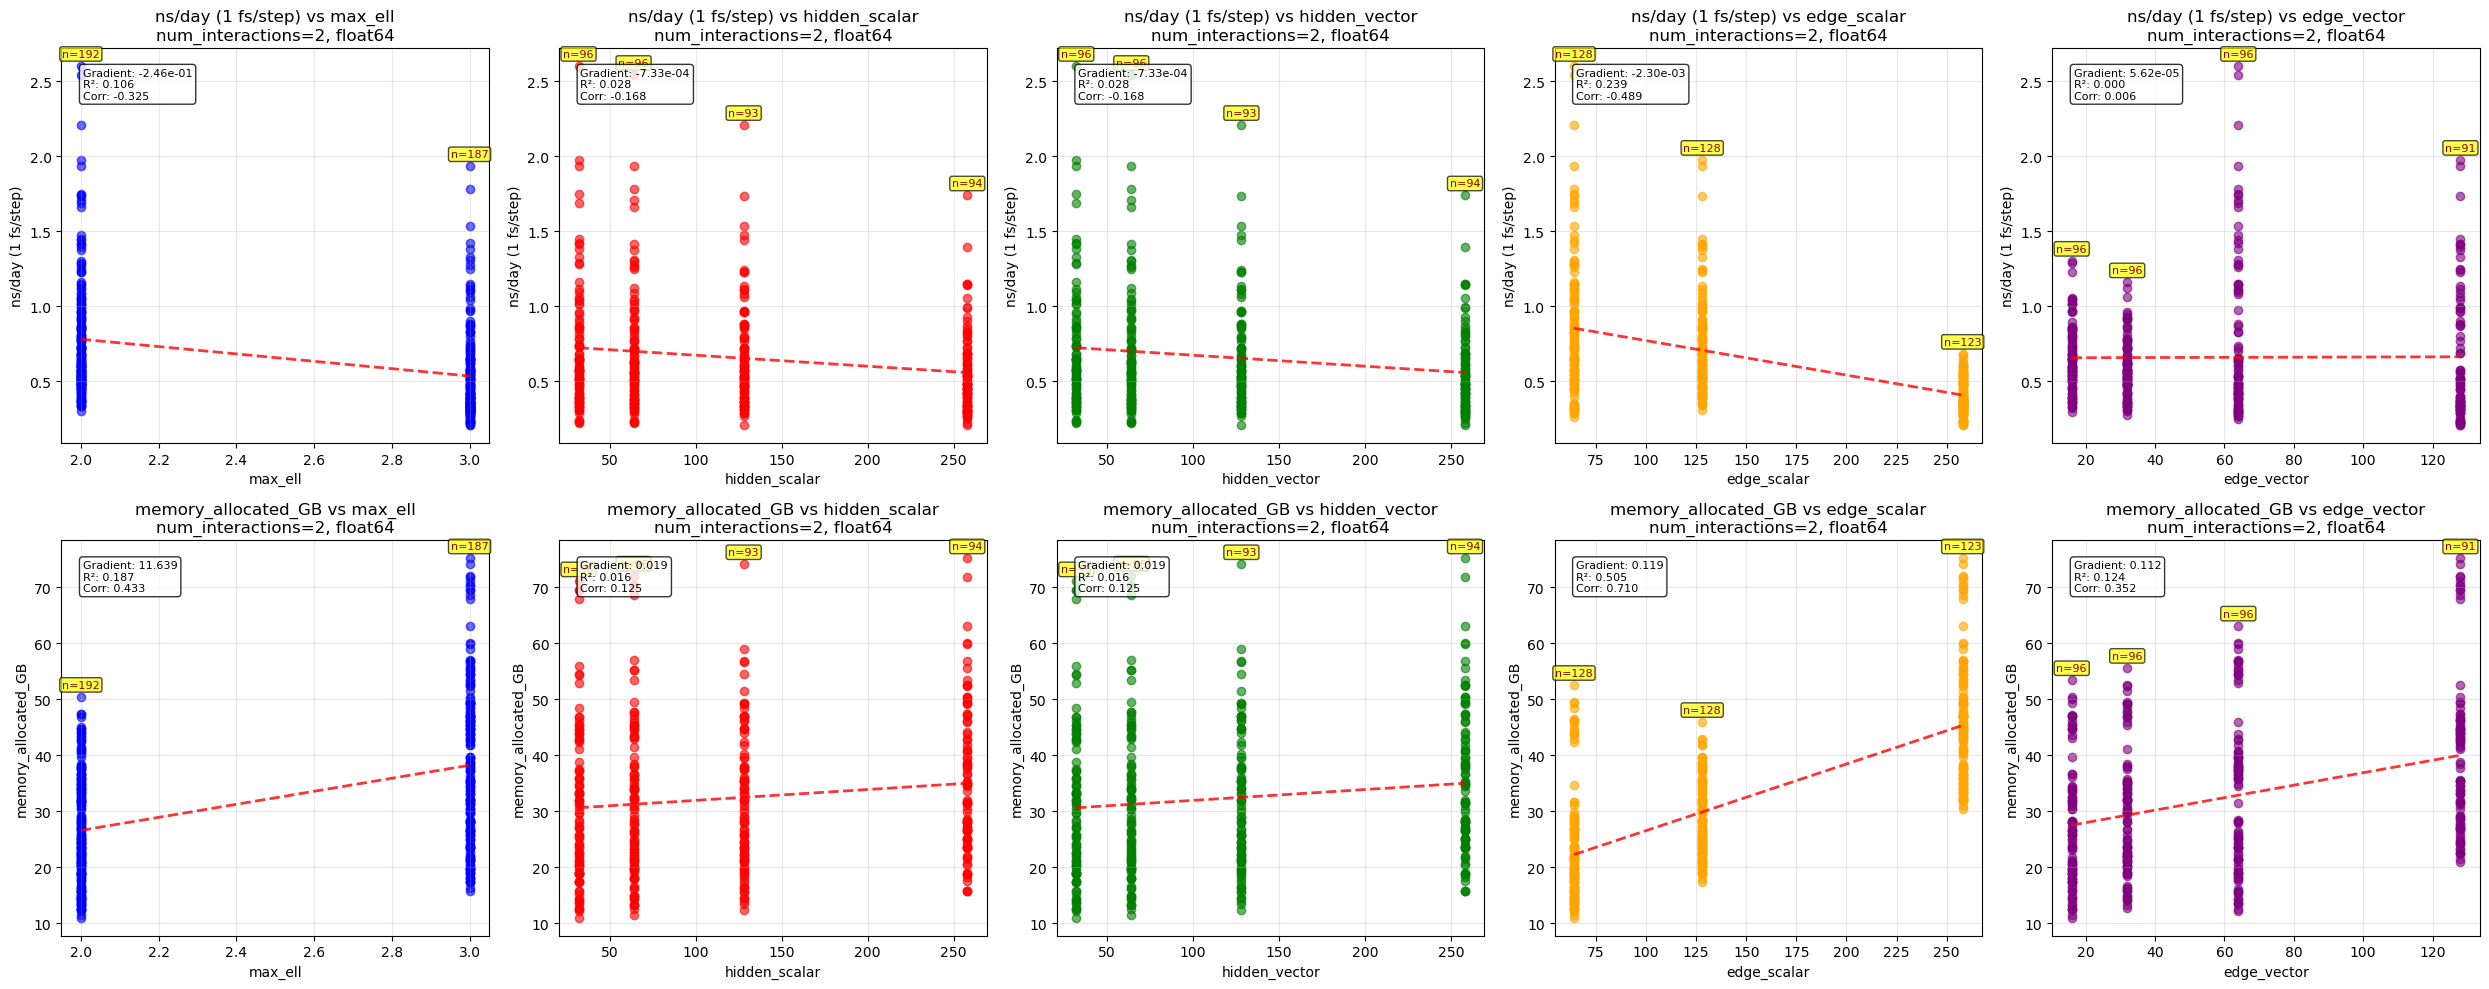

In [7]:
# Analysis for num_interactions == 2, dtype == float64
print("="*80)
print("ANALYSIS: num_interactions=2, dtype=float64")
print("="*80)

df_subset = df[(df['num_interactions'] == 2) & (df['dtype'] == 'float64')]
print(f"Number of configurations: {len(df_subset)}")

plot_hyperparameter_analysis(
    df_subset, 
    "num_interactions=2, float64", 
    numerical_hyperparams, 
    key_performance_metric, 
    'memory_allocated_GB'
)

In [8]:
# Summary table of regression statistics across all configurations
print("="*100)
print("SUMMARY: REGRESSION STATISTICS ACROSS ALL CONFIGURATIONS")
print("="*100)

configurations = [
    ("num_interactions=1, float32", (df['num_interactions'] == 1) & (df['dtype'] == 'float32')),
    ("num_interactions=1, float64", (df['num_interactions'] == 1) & (df['dtype'] == 'float64')),
    ("num_interactions=2, float32", (df['num_interactions'] == 2) & (df['dtype'] == 'float32')),
    ("num_interactions=2, float64", (df['num_interactions'] == 2) & (df['dtype'] == 'float64'))
]

# Create summary table
summary_data = []

for config_name, mask in configurations:
    df_subset = df[mask]
    
    for param in numerical_hyperparams:
        if param in df_subset.columns:
            x_data = df_subset[param].values
            y_perf = df_subset[key_performance_metric].values
            y_mem = df_subset['memory_allocated_GB'].values
            
            # Performance stats
            grad_perf, r2_perf, corr_perf = calculate_regression_stats(x_data, y_perf)
            
            # Memory stats  
            grad_mem, r2_mem, corr_mem = calculate_regression_stats(x_data, y_mem)
            
            summary_data.append({
                'Configuration': config_name,
                'Hyperparameter': param,
                'Performance_Gradient': grad_perf,
                'Performance_R²': r2_perf,
                'Performance_Correlation': corr_perf,
                'Memory_Gradient': grad_mem,
                'Memory_R²': r2_mem,
                'Memory_Correlation': corr_mem,
                'Sample_Size': len(df_subset)
            })

# Convert to DataFrame for better display
summary_df = pd.DataFrame(summary_data)

# Display summary grouped by hyperparameter
for param in numerical_hyperparams:
    param_data = summary_df[summary_df['Hyperparameter'] == param]
    if len(param_data) > 0:
        print(f"\n{param.upper()} ANALYSIS ACROSS CONFIGURATIONS:")
        print("-" * 80)
        display_cols = ['Configuration', 'Performance_Gradient', 'Performance_R²', 'Performance_Correlation', 
                       'Memory_Gradient', 'Memory_R²', 'Memory_Correlation', 'Sample_Size']
        print(param_data[display_cols].to_string(index=False, float_format='{:.4f}'.format))
        
        # Highlight strongest correlations
        perf_corr_abs = param_data['Performance_Correlation'].abs()
        mem_corr_abs = param_data['Memory_Correlation'].abs()
        
        if not perf_corr_abs.isna().all():
            strongest_perf_idx = perf_corr_abs.idxmax()
            strongest_perf_config = param_data.loc[strongest_perf_idx, 'Configuration']
            strongest_perf_corr = param_data.loc[strongest_perf_idx, 'Performance_Correlation']
            print(f"  → Strongest performance correlation: {strongest_perf_config} (r={strongest_perf_corr:.3f})")
        
        if not mem_corr_abs.isna().all():
            strongest_mem_idx = mem_corr_abs.idxmax()
            strongest_mem_config = param_data.loc[strongest_mem_idx, 'Configuration']
            strongest_mem_corr = param_data.loc[strongest_mem_idx, 'Memory_Correlation']
            print(f"  → Strongest memory correlation: {strongest_mem_config} (r={strongest_mem_corr:.3f})")

SUMMARY: REGRESSION STATISTICS ACROSS ALL CONFIGURATIONS

MAX_ELL ANALYSIS ACROSS CONFIGURATIONS:
--------------------------------------------------------------------------------
              Configuration  Performance_Gradient  Performance_R²  Performance_Correlation  Memory_Gradient  Memory_R²  Memory_Correlation  Sample_Size
num_interactions=1, float32               -0.9858          0.0850                  -0.2916           2.0301     0.0725              0.2692          384
num_interactions=1, float64               -0.7490          0.0542                  -0.2328           3.7239     0.0736              0.2713          384
num_interactions=2, float32               -0.3945          0.1553                  -0.3941           6.3441     0.1942              0.4407          384
num_interactions=2, float64               -0.2456          0.1058                  -0.3253          11.6393     0.1872              0.4327          379
  → Strongest performance correlation: num_interactions=2, fl

# Investigating Edge Irreps

I believe that having larger edge irreps leads to out-of-memory errors, that skew the result. In the following cells, I do the above plots but with other hypers fixed (so fewer data points).

In [9]:
# First, let's examine the data for out-of-memory issues
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values or extreme outliers that might indicate OOM errors
print("Data quality check:")
print(f"Total configurations: {len(df)}")
print(f"Configurations with missing performance data: {df[key_performance_metric].isna().sum()}")
print(f"Configurations with missing memory data: {df['memory_allocated_GB'].isna().sum()}")

# Look at the distribution of edge irreps values
print(f"\nEdge scalar distribution:")
print(df['edge_scalar'].value_counts().sort_index())
print(f"\nEdge vector distribution:")
print(df['edge_vector'].value_counts().sort_index())

# Check for any extreme values that might indicate errors
print(f"\nPerformance metric range: {df[key_performance_metric].min():.3f} - {df[key_performance_metric].max():.3f}")
print(f"Memory range: {df['memory_allocated_GB'].min():.2f} - {df['memory_allocated_GB'].max():.2f} GB")

# Identify potentially problematic configurations
very_slow = df[df[key_performance_metric] > df[key_performance_metric].quantile(0.95)]
very_memory_intensive = df[df['memory_allocated_GB'] > df['memory_allocated_GB'].quantile(0.95)]

print(f"\nVery slow configurations (top 5%): {len(very_slow)}")
print(f"Very memory-intensive configurations (top 5%): {len(very_memory_intensive)}")

# Check if these are correlated with large edge irreps
print(f"\nCorrelation of extreme values with edge parameters:")
print(f"Edge scalar correlation with slow performance: {very_slow['edge_scalar'].corr(very_slow[key_performance_metric]):.3f}")
print(f"Edge vector correlation with slow performance: {very_slow['edge_vector'].corr(very_slow[key_performance_metric]):.3f}")
print(f"Edge scalar correlation with high memory: {very_memory_intensive['edge_scalar'].corr(very_memory_intensive['memory_allocated_GB']):.3f}")
print(f"Edge vector correlation with high memory: {very_memory_intensive['edge_vector'].corr(very_memory_intensive['memory_allocated_GB']):.3f}")

Data quality check:
Total configurations: 1531
Configurations with missing performance data: 0
Configurations with missing memory data: 0

Edge scalar distribution:
edge_scalar
64     512
128    512
258    507
Name: count, dtype: int64

Edge vector distribution:
edge_vector
16     384
32     384
64     384
128    379
Name: count, dtype: int64

Performance metric range: 0.206 - 8.405
Memory range: 1.69 - 75.19 GB

Very slow configurations (top 5%): 77
Very memory-intensive configurations (top 5%): 77

Correlation of extreme values with edge parameters:
Edge scalar correlation with slow performance: 0.075
Edge vector correlation with slow performance: 0.050
Edge scalar correlation with high memory: 0.289
Edge vector correlation with high memory: 0.372


IF we remove systems with edge_scalar=258 and edge_vector=379...

ANALYSIS: num_interactions=2, dtype=float64
Number of configurations: 192


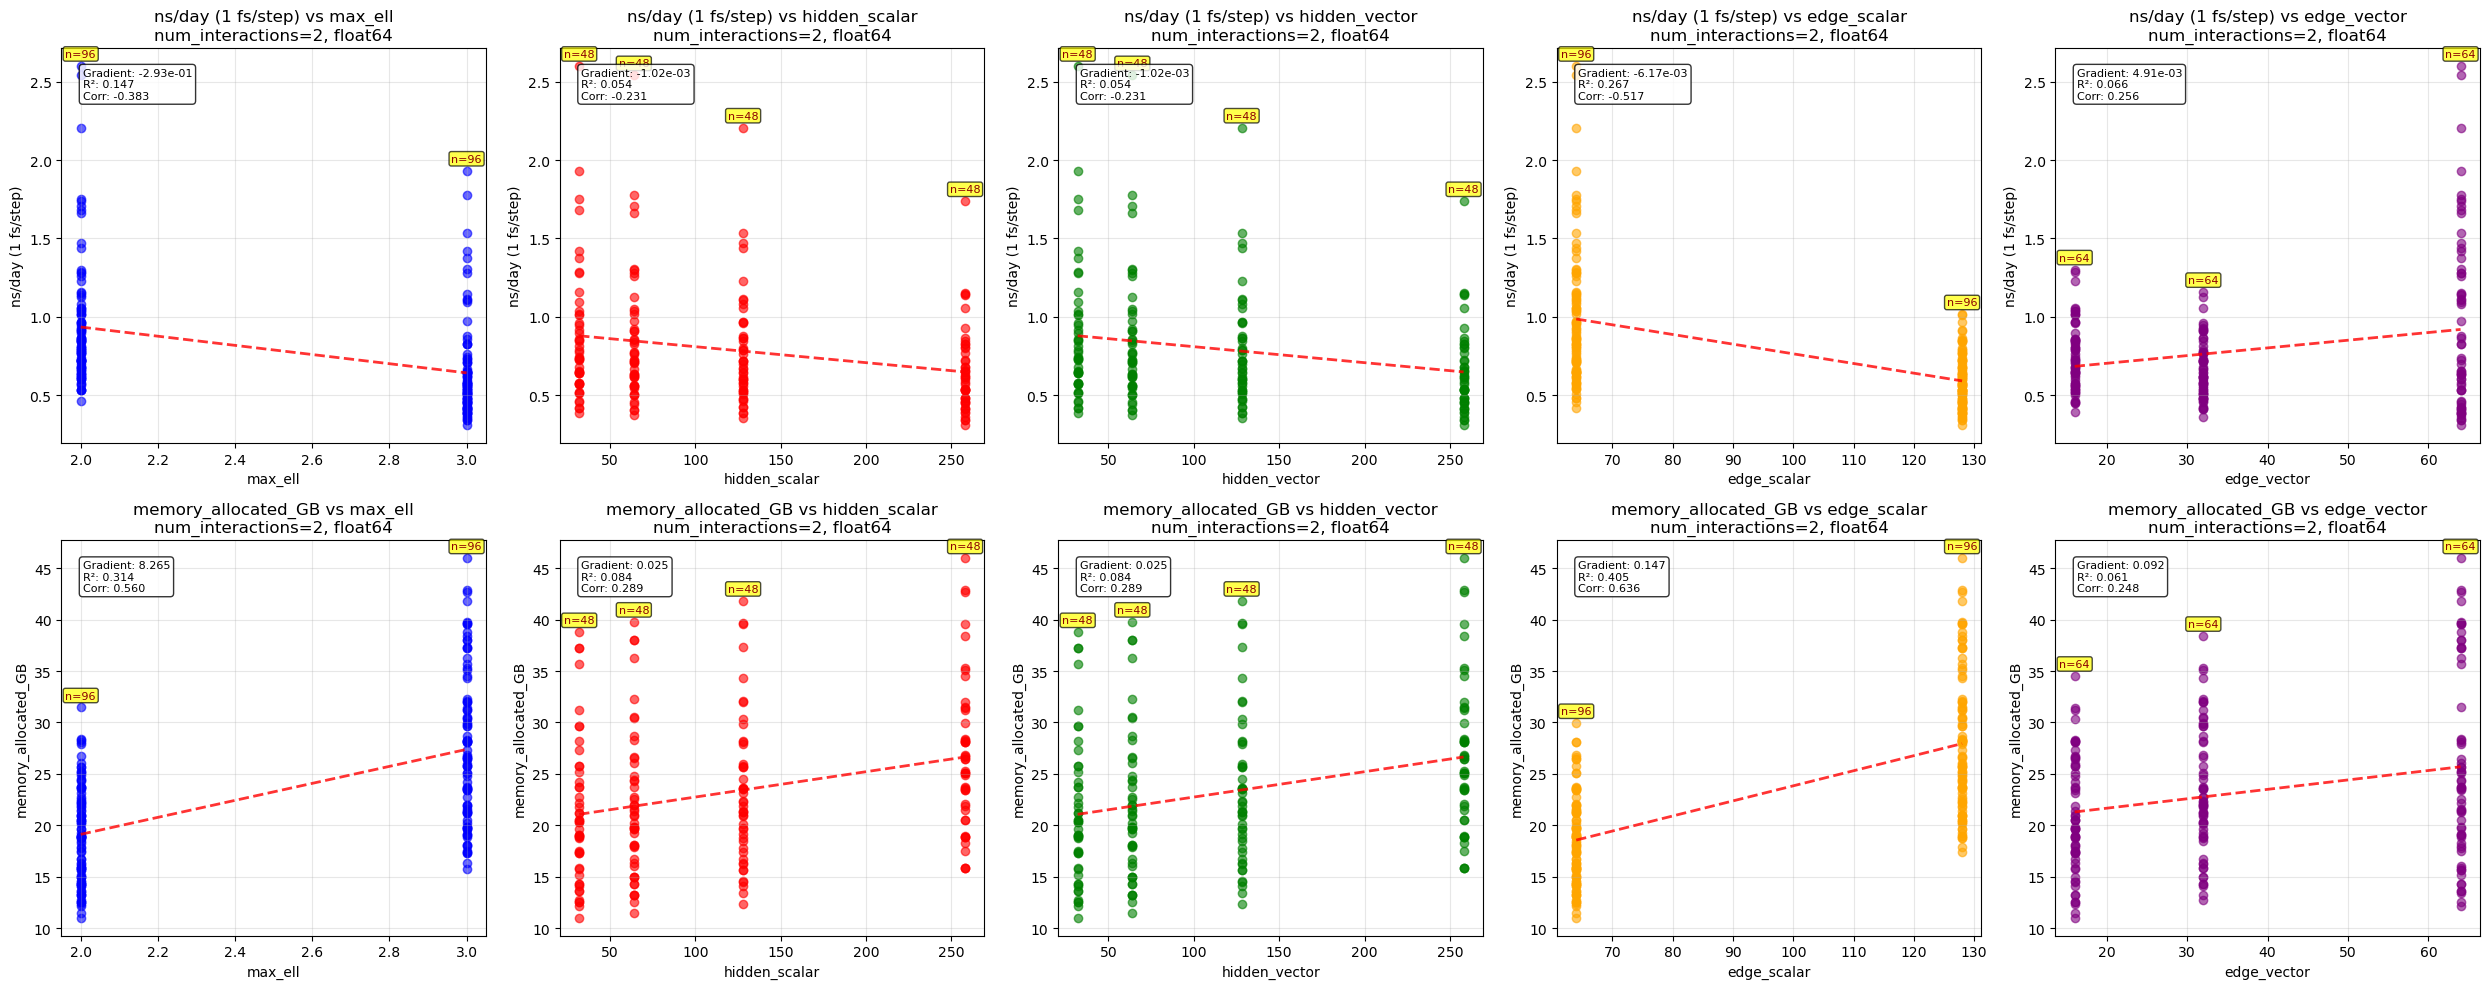

In [10]:
# Analysis for num_interactions == 2, dtype == float64
print("="*80)
print("ANALYSIS: num_interactions=2, dtype=float64")
print("="*80)

df_subset = df[(df['num_interactions'] == 2) & (df['dtype'] == 'float64') & (df['edge_scalar'] < 256) & (df['edge_vector'] < 128)]
print(f"Number of configurations: {len(df_subset)}")

plot_hyperparameter_analysis(
    df_subset, 
    "num_interactions=2, float64", 
    numerical_hyperparams, 
    key_performance_metric, 
    'memory_allocated_GB'
)